In [1]:
from openqdc.datasets import Spice
dataset = Spice() # Cela téléchargera et mettra en cache le dataset automatiquement

2026-04-27 10:39:57.394 | INFO     | openqdc.datasets.base:read_preprocess:435 - Reading preprocessed data.
2026-04-27 10:39:57.395 | INFO     | openqdc.datasets.base:read_preprocess:436 - Dataset spice with the following units:
                     Energy: hartree,
                     Distance: bohr,
                     Forces: hartree/bohr
2026-04-27 10:39:57.803 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded atomic_inputs with shape (33175288, 5), dtype float32
2026-04-27 10:39:57.804 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded position_idx_range with shape (1110165, 2), dtype int32
2026-04-27 10:39:57.805 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded energies with shape (1110165, 1), dtype float64
2026-04-27 10:39:57.805 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded forces with shape (33175288, 3, 1), dtype float32
2026-04-27 10:39:57.806 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded name w

In [ ]:
from collections import Counter

# Formule cible pour l'alanine dipeptide (Ac-Ala-NHMe)
# Carbone: 5, Hydrogène: 10, Azote: 2, Oxygène: 2
target_counts = {6: 5, 1: 10, 7: 2, 8: 2}

ala_indices = []

for i in range(len(dataset)):
    # Compter les numéros atomiques (6=C, 1=H, 7=N, 8=O)
    counts = Counter(dataset[i]['atomic_numbers'])
    
    # Vérifier si ça match notre alanine
    if all(counts[k] == v for k, v in target_counts.items()) and len(counts) == 4:
        ala_indices.append(i)
        print(f"Match trouvé à l'index {i} | SMILES: {dataset[i]['name']}")



Match trouvé à l'index 185598 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3]=[O:1]
Match trouvé à l'index 185599 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3]=[O:1]
Match trouvé à l'index 185600 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3]=[O:1]
Match trouvé à l'index 185601 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3]=[O:1]
Match trouvé à l'index 185602 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3]=[O:1]
Match trouvé à l'index 185603 | SMILES: [H:11][C:6]([H:12])([H:13])[C:4](=[O:2])[C:8]([H:16])([H:17])[C:9]([H:18])([H:19])[N:5]([H:10])[C:7]([H:14])([H:15])[N:3

In [23]:
alanine_data =[dataset[ala_indices[i]] for i in range(len(ala_indices))]   

<>:49: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:50: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:49: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:50: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_52960/1523996492.py:49: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel("$\phi$ (degrés)")
/tmp/ipykernel_52960/1523996492.py:50: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string

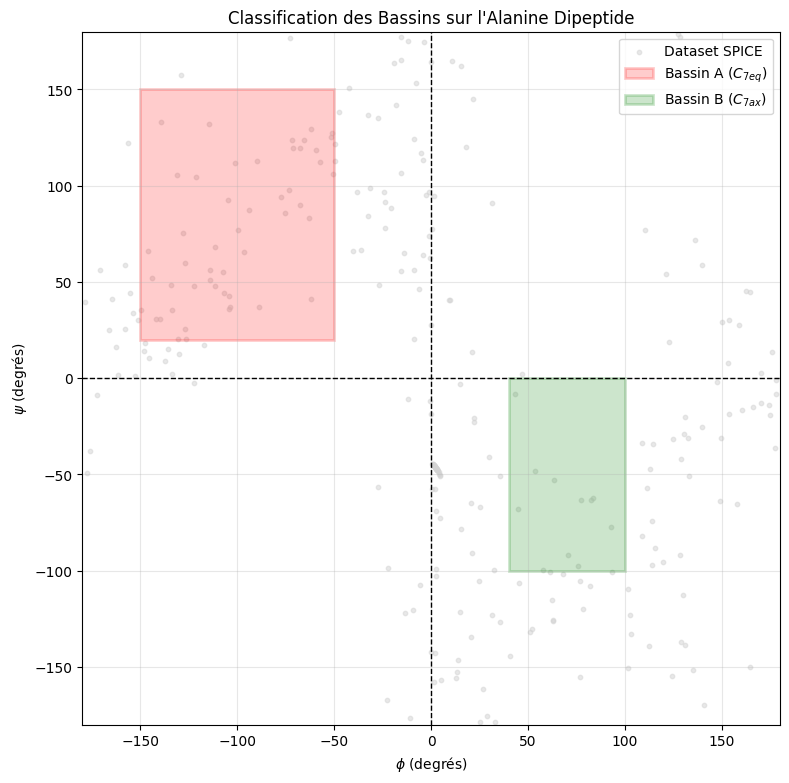

In [34]:
import matplotlib.pyplot as plt
from ase import Atoms
import numpy as np

# On récupère les données
pos = [conf['positions'] for conf in alanine_data]  # Shape (N, 19, 3)
z = [conf['atomic_numbers'] for conf in alanine_data]

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ase import Atoms
import numpy as np

# Indices corrigés pour SPICE (Ac-Ala-NHMe)
phi_indices = [4, 6, 8, 13]
psi_indices = [6, 8, 13, 15]

phis = []
psis = []

for i in range(len(pos)):
    atoms = Atoms(numbers=z[i], positions=pos[i])
    p = atoms.get_dihedral(*phi_indices)
    s = atoms.get_dihedral(*psi_indices)
    
    # Normalisation [-180, 180]
    phis.append(p - 360 if p > 180 else p)
    psis.append(s - 360 if s > 180 else s)

plt.figure(figsize=(9, 9))

# Plot des points du dataset
plt.scatter(phis, psis, s=10, color='lightgray', alpha=0.5, label='Dataset SPICE')

# Définition des zones (approximations standard)
# Bassin A (C7eq) : phi ~ -80, psi ~ 70
bassin_A = patches.Rectangle((-150, 20), 100, 130, linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, label='Bassin A ($C_{7eq}$)')
# Bassin B (C7ax) : phi ~ 60, psi ~ -60
bassin_B = patches.Rectangle((40, -100), 60, 100, linewidth=2, edgecolor='green', facecolor='green', alpha=0.2, label='Bassin B ($C_{7ax}$)')

ax = plt.gca()
ax.add_patch(bassin_A)
ax.add_patch(bassin_B)

# Cosmétique
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.title("Classification des Bassins sur l'Alanine Dipeptide")
plt.xlabel("$\phi$ (degrés)")
plt.ylabel("$\psi$ (degrés)")
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()